In [1]:
## import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)

In [2]:
## dataset 
df = pd.read_csv("../data/processed/amazon_sales_feature_engineered.csv")

C:\Users\SVS\AppData\Local\Temp\ipykernel_17756\1057184150.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/amazon_sales_feature_engineered.csv")


In [3]:
print(df.shape)
df.head()
df.info()

(128029, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128029 entries, 0 to 128028
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idx                     128029 non-null  int64  
 1   order_id                128029 non-null  object 
 2   order_date              128029 non-null  object 
 3   status                  128029 non-null  object 
 4   fulfilment              128029 non-null  object 
 5   sales_channel           128029 non-null  object 
 6   ship_service_level      128029 non-null  object 
 7   style                   128029 non-null  object 
 8   sku                     128029 non-null  object 
 9   category                128029 non-null  object 
 10  size                    128029 non-null  object 
 11  asin                    128029 non-null  object 
 12  courier_status          121170 non-null  object 
 13  qty                     128029 non-null  int64  
 14  currenc

In [4]:
df.describe()

,idx,qty,amount,ship_postal_code,z_score,return_flag,fulfillment_efficiency
count,128029.000000,128029.000000,128029.000000,127996.000000,128029.000000,128029.000000,128029.000000
mean,64453.341024,0.902592,638.738539,463896.230999,-0.026359,0.142702,0.851518
std,37270.354467,0.310110,259.376409,191444.229439,0.950871,0.349770,0.366589
min,0.000000,0.000000,0.000000,110001.000000,-2.367967,0.000000,0.000000
25%,32123.000000,1.000000,458.000000,382421.000000,-0.688944,0.000000,1.000000
50%,64449.000000,1.000000,605.000000,500033.000000,-0.150044,0.000000,1.000000
75%,96767.000000,1.000000,771.000000,600024.000000,0.458510,0.000000,1.000000
max,128974.000000,15.000000,1463.000000,989898.000000,2.995373,1.000000,15.000000


In [5]:
print("Mean Order Amount :", round(df["amount"].mean(),2))
print("Median Order Amount :", round(df["amount"].median(),2))
print("Mean Quantity Sold :", round(df["qty"].mean(),2))
print("Median Quantity Sold :", round(df["qty"].median(),2))

Mean Order Amount : 638.74
Median Order Amount : 605.0
Mean Quantity Sold : 0.9
Median Quantity Sold : 1.0


In [6]:
## SKU Counts 
print("Total Unique SKUs :", df["sku"].nunique())
sku_counts = (df["sku"].value_counts().head(10))
print(sku_counts)

Total Unique SKUs : 7173
sku
JNE3797-KR-L      772
JNE3797-KR-M      655
JNE3797-KR-S      586
JNE3405-KR-L      534
J0230-SKD-M       505
JNE3797-KR-XL     472
J0230-SKD-S       450
JNE3405-KR-S      443
JNE3797-KR-XS     429
JNE3797-KR-XXL    395
Name: count, dtype: int64


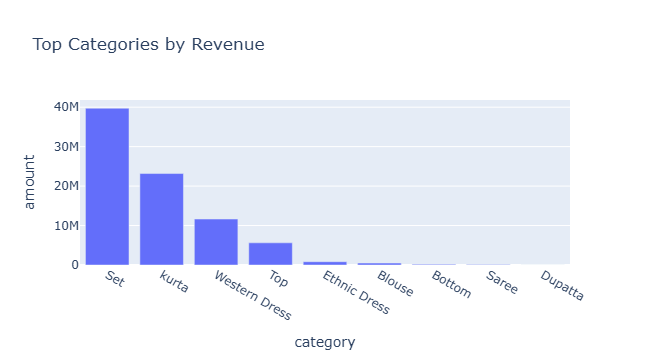

In [7]:
## Top 10 categories by Revenue 
category_revenue = (
    df.groupby("category")["amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    category_revenue,
    x="category",
    y="amount",
    title="Top Categories by Revenue"
)

fig.show()

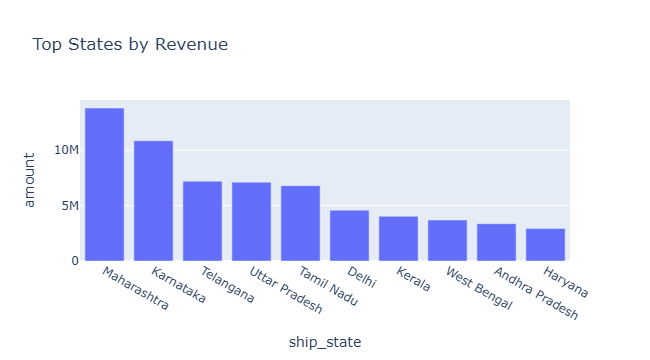

In [8]:
## Top 10 States by Revenue 
state_revenue = (
    df.groupby("ship_state")["amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    state_revenue,
    x="ship_state",
    y="amount",
    title="Top States by Revenue"
)

fig.show()

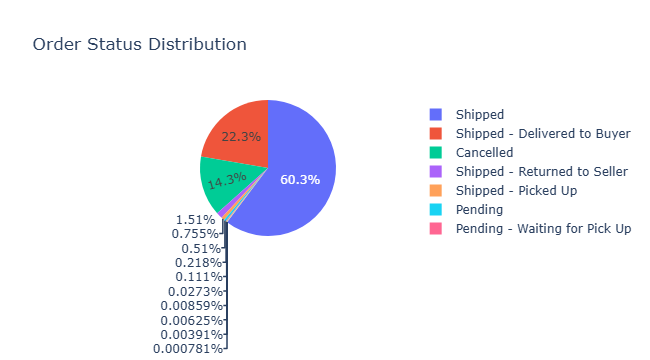

In [9]:
## order ststus Distribution 
status_counts = (
    df["status"]
      .value_counts()
      .reset_index()
)

status_counts.columns = ["status", "count"]

fig = px.pie(
    status_counts,
    names="status",
    values="count",
    title="Order Status Distribution"
)

fig.show()

In [10]:
print("Total Orders :", len(df))
print("Total Revenue :", round(df["amount"].sum(),2))
print("Average Revenue :", round(df["amount"].mean(),2))
print("Unique Categories :", df["category"].nunique())
print("Unique States :", df["ship_state"].nunique())
print("Unique SKUs :", df["sku"].nunique())

Total Orders : 128029
Total Revenue : 81777056.42
Average Revenue : 638.74
Unique Categories : 9
Unique States : 36
Unique SKUs : 7173


In [12]:
summary = pd.DataFrame({
    "Metric":[
        "Total Orders",
        "Total Revenue",
        "Average Revenue",
        "Median Revenue",
        "Unique Categories",
        "Unique States",
        "Unique SKUs"
    ],
    "Value":[
        len(df),
        df["amount"].sum(),
        df["amount"].mean(),
        df["amount"].median(),
        df["category"].nunique(),
        df["ship_state"].nunique(),
        df["sku"].nunique()
    ]
})

summary.to_csv(
    "../data/processed/Python_EDA_Summary.csv",
    index=False
)

print("EDA Summary Exported Successfully")

EDA Summary Exported Successfully
